<a href="https://colab.research.google.com/github/SanjaraT/PyTorch-from-beginning/blob/main/ANN_PyTorch_small_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
df = pd.read_csv("/content/drive/MyDrive/fashion_mnist-dataset/fashion-mnist_train.csv")

In [4]:
# df = pd.read_csv("fmnist_small.csv")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


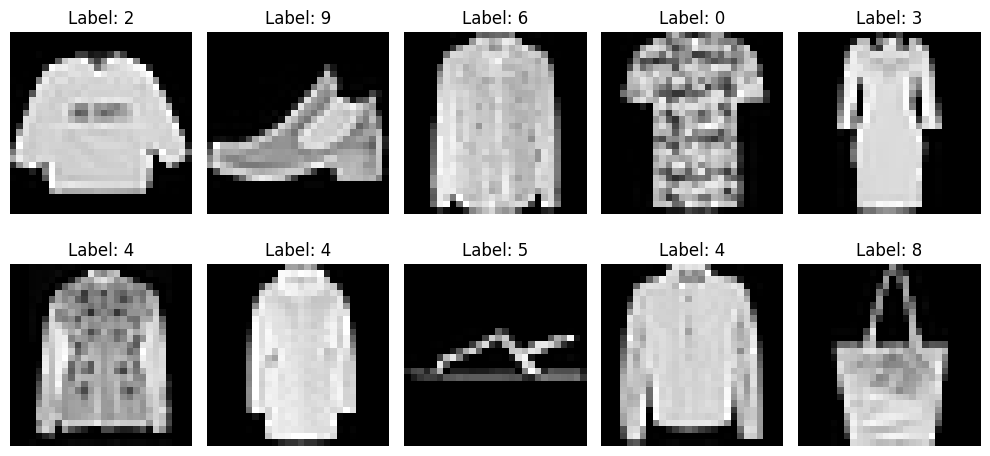

In [6]:
# Data Visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
df.shape

(60000, 785)

In [4]:
# Data Split
X = df.drop('label', axis=1).values
y = df['label'].values

In [9]:
X.shape

(60000, 784)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for balanced classes
)

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
# Custom Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]



In [8]:
# train-test dataset object
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [9]:
# train-test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:
import torch.nn as nn
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [29]:
# NN Class
import torch.nn as nn
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(64, 10)
    )
  def forward(self, x):
    return self.model(x)

In [30]:
# Epochs and learning rate
e = 100
lr = 0.1

In [32]:

# class object
model = MyNN(X_train.shape[1])
model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)


In [33]:

# training loop
for epoch in range(e):
  total_epoch_loss = 0
  for batch_fetaures, batch_labels in train_dataloader:

    batch_fetaures = batch_fetaures.to(device)
    batch_labels = batch_labels.to(device)

    # forward pass
    ouputs = model(batch_fetaures)
    loss = criterion(ouputs, batch_labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f'Epoch {epoch+1}/{e}, Loss: {avg_loss:.4f}')

Epoch 1/100, Loss: 0.6236
Epoch 2/100, Loss: 0.4951
Epoch 3/100, Loss: 0.4565
Epoch 4/100, Loss: 0.4319
Epoch 5/100, Loss: 0.4143
Epoch 6/100, Loss: 0.3992
Epoch 7/100, Loss: 0.3889
Epoch 8/100, Loss: 0.3816
Epoch 9/100, Loss: 0.3733
Epoch 10/100, Loss: 0.3678
Epoch 11/100, Loss: 0.3600
Epoch 12/100, Loss: 0.3580
Epoch 13/100, Loss: 0.3532
Epoch 14/100, Loss: 0.3451
Epoch 15/100, Loss: 0.3430
Epoch 16/100, Loss: 0.3383
Epoch 17/100, Loss: 0.3335
Epoch 18/100, Loss: 0.3319
Epoch 19/100, Loss: 0.3312
Epoch 20/100, Loss: 0.3258
Epoch 21/100, Loss: 0.3239
Epoch 22/100, Loss: 0.3231
Epoch 23/100, Loss: 0.3146
Epoch 24/100, Loss: 0.3151
Epoch 25/100, Loss: 0.3114
Epoch 26/100, Loss: 0.3112
Epoch 27/100, Loss: 0.3114
Epoch 28/100, Loss: 0.3080
Epoch 29/100, Loss: 0.3065
Epoch 30/100, Loss: 0.3039
Epoch 31/100, Loss: 0.3049
Epoch 32/100, Loss: 0.3031
Epoch 33/100, Loss: 0.3023
Epoch 34/100, Loss: 0.2997
Epoch 35/100, Loss: 0.2964
Epoch 36/100, Loss: 0.2932
Epoch 37/100, Loss: 0.2939
Epoch 38/1

In [34]:
# model evaluation
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [39]:
total =0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_dataloader:

    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)
    _, pred = torch.max(outputs, 1)
    total += batch_labels.size(0)
    correct = correct + (pred == batch_labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')


Test Accuracy: 89.00%


In [40]:
with torch.no_grad():
  for batch_features, batch_labels in train_dataloader:

    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)
    _, pred = torch.max(outputs, 1)
    total += batch_labels.size(0)
    correct = correct + (pred == batch_labels).sum().item()

accuracy = correct / total
print(f'Train Accuracy: {accuracy * 100:.2f}%')

Train Accuracy: 93.16%
